In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point, LineString, Polygon
import utils
from shapely import wkt
import matplotlib.pyplot as plt
from pyproj import Transformer, CRS
import manifold3d as m3d
import trimesh
import pyvista as pv
pv.OFF_SCREEN = True
%matplotlib widget

import trimesh


In [2]:
def show_manifold(manifold):
    raw = manifold.to_mesh()
    tm = trimesh.Trimesh(
        vertices=raw.vert_properties[:, :3],
        faces=raw.tri_verts
    )
    return tm.show()

def latlon_to_xy_displacement(lons, lats, lon0, lat0):
    # Create an azimuthal equidistant projection centered on your origin point
    aeqd_crs = CRS.from_proj4(f'+proj=aeqd +lat_0={lat0} +lon_0={lon0} +units=m')
    transformer = Transformer.from_crs("EPSG:4326", aeqd_crs, always_xy=True)
    
    xs, ys = transformer.transform(lons, lats)  # returns meters from origin
    return xs, ys
    
def show_manifold_pv(manifold):
    raw = manifold.to_mesh()
    verts = raw.vert_properties[:, :3]
    faces = raw.tri_verts

    # PyVista needs faces prefixed with the count (3 for triangles)
    pv_faces = np.hstack([np.full((len(faces), 1), 3), faces])
    mesh = pv.PolyData(verts, pv_faces)

    plotter = pv.Plotter()
    plotter.add_mesh(mesh, scalars=verts[:, 2], cmap='viridis')  # color by depth
    plotter.show()

def dem_to_structuredgrid(depth_grid, transform, lon0, lat0):
    """
    depth_grid: 2D numpy array from rasterio (rows, cols)
    transform: Affine transform from rasterio dataset.transform
    """
    
    nrows, ncols = depth_grid.shape
    
    # Generate pixel coordinates (col, row) for each cell
    cols, rows = np.meshgrid(np.arange(ncols), np.arange(nrows))


    
    
    # Convert pixel coords to spatial coords using the affine transform
    xs, ys = transform * (cols, rows)

    print(xs, ys)
    xs, ys = latlon_to_xy_displacement(xs, ys, lon0, lat0)
    
    zs = depth_grid  # use depth values as Z (negate if depths are positive-down)
    print(zs.min(), zs.max()) 

    # PyVista StructuredGrid expects (X, Y, Z) each of shape (nrows, ncols)
    grid = pv.StructuredGrid(xs, ys, zs)
    print(grid.dimensions)   # e.g. (500, 300, 1)
    print(grid.points.shape) # e.g. (150000, 3)
    print(xs.shape) 
    
    return grid


def plot_structured_grid_3d(grid, cmap='viridis', step=1):
    # Extract points and reshape back to grid shape
    nrows, ncols = grid.dimensions[:2]  # StructuredGrid dimensions
    points = grid.points  # (N, 3) array of XYZ

    xs = points[:, 0].reshape(nrows, ncols)
    ys = points[:, 1].reshape(nrows, ncols)
    zs = points[:, 2].reshape(nrows, ncols)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(
        xs[::step, ::step],
        ys[::step, ::step],
        zs[::step, ::step],
        cmap=cmap,
        linewidth=0,
        antialiased=False
    )
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Depth (m)')
    plt.tight_layout()
    plt.show()

In [3]:
ls =  "LINESTRING (-68.8 43.7, -68.2 43.95, -67.6 43.75, -67.0 44.0)" 
geom = wkt.loads(ls)
line_gdf = gpd.GeoDataFrame(geometry=[geom], crs=utils.wgs84)

In [4]:
gebco_dir = "../opprotunisticsonarscan/gebco_contour/"

In [5]:
beam = utils.load_beam("./EM302nautilus.txt")

In [6]:
max_width = utils.max_width(beam)
envelope = utils.line_to_ellipse(line_gdf, width=max_width*1.1, resolution = 4)  # Example width of 100 km+
m = utils.Map(envelope, gebco_dir, extinction_file="EM302nautilus.txt")

In [7]:
lon0, lat0 = line_gdf.loc[0].geometry.coords[0]
lon0, lat0

(-68.8, 43.7)

In [8]:

depth_grid = m.depth_raster.astype(float)
depth_grid[depth_grid >= -2] = 2*np.nanmin(depth_grid.flatten())
sg = dem_to_structuredgrid(depth_grid, m.depth_transform, lon0, lat0)

[[-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]
 [-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]
 [-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]
 ...
 [-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]
 [-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]
 [-68.85833333 -68.85416667 -68.85       ... -66.95416667 -66.95
  -66.94583333]] [[44.06666667 44.06666667 44.06666667 ... 44.06666667 44.06666667
  44.06666667]
 [44.0625     44.0625     44.0625     ... 44.0625     44.0625
  44.0625    ]
 [44.05833333 44.05833333 44.05833333 ... 44.05833333 44.05833333
  44.05833333]
 ...
 [43.64583333 43.64583333 43.64583333 ... 43.64583333 43.64583333
  43.64583333]
 [43.64166667 43.64166667 43.64166667 ... 43.64166667 43.64166667
  43.64166667]
 [43.6375     43.6375     43.6375     ... 43.6375     43.6375
  43.6375    ]]
-478.0 -43.0
(104, 460, 

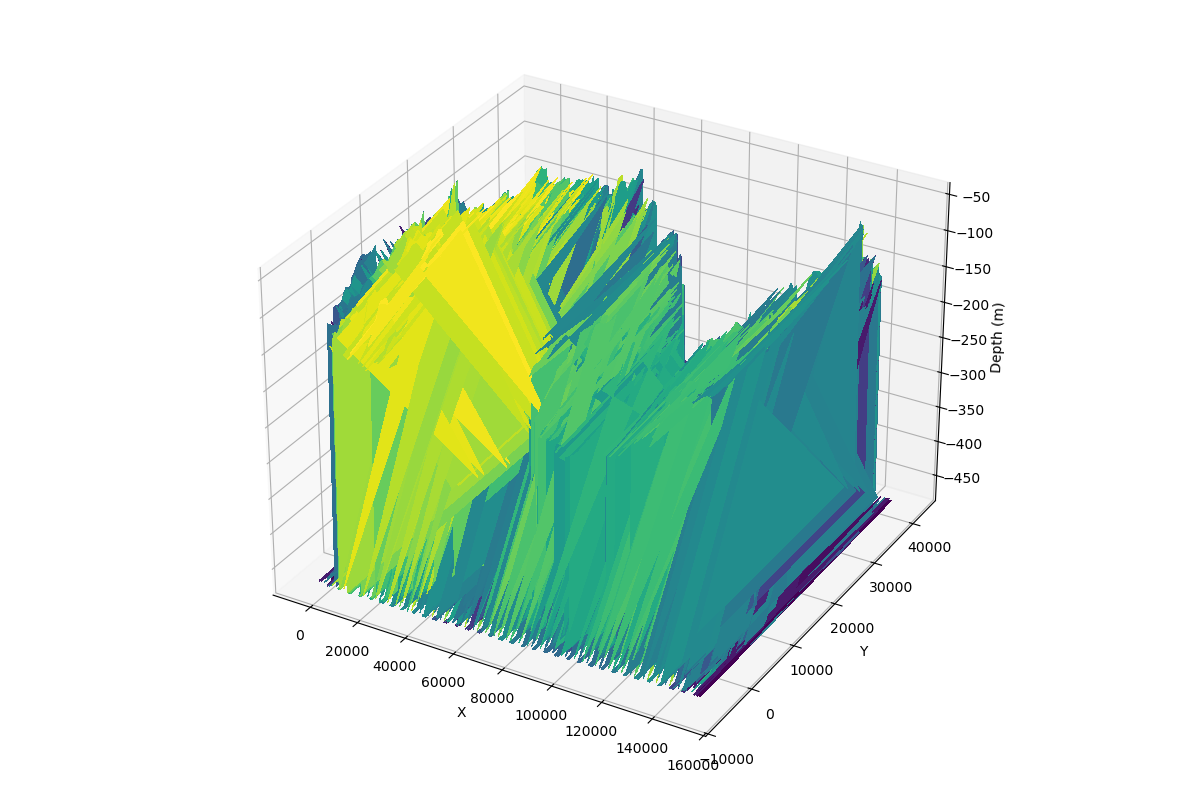

In [9]:
plot_structured_grid_3d(sg)

In [10]:
ls

'LINESTRING (-68.8 43.7, -68.2 43.95, -67.6 43.75, -67.0 44.0)'

In [23]:
seafloor_mesh = sg.extract_surface(algorithm ='dataset_surface' )
seafloor_mesh.save('dem_solid.stl')

In [12]:
list(depth_grid.flatten())

[np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-478.0),
 np.float64(-

In [13]:
m.width_at_depth(-1608)

np.float64(10612.8)

In [14]:
points1 = [(0, 0)]
points2 = []
for depth in m.beam.index:
    width = m.width_at_depth(-depth)
    points1.append((float(-width/2), -depth))
    points2.append((float(width/2), -depth))
pgon = Polygon(points1 + list(reversed(points2)))

In [15]:
def sweep_sonar_along_track(polygon, linestring,  save_path='sonar_volume.stl'):
    """
    Sweeps a 2D sonar cross-section polygon along a ship track.
    The polygon is in the (across-track, depth) plane and is rotated
    to always be perpendicular to the ship's heading.
    
    polygon: 2D shapely polygon where X=across-track, Y=depth
    linestring: 2D shapely linestring representing ship track (X, Y) in world coords
    """
    anchor = np.array(polygon.exterior.coords[0])
    poly_coords = np.array(polygon.exterior.coords[:-1])
    relative_coords = poly_coords - anchor  # (N_verts, 2) in local (across, depth) space

    line_points = np.array(linestring.coords)  # (N, 2)
    n_line = len(line_points)
    n_verts = len(poly_coords)

    all_points = []
    for i, lp in enumerate(line_points):
        # Compute heading direction at this point
        if i < n_line - 1:
            direction = line_points[i + 1] - line_points[i]
        else:
            direction = line_points[i] - line_points[i - 1]
        
        direction = direction / np.linalg.norm(direction)  # normalize
        
        # Build a coordinate frame:
        # forward = along track (in XY plane)
        # across  = perpendicular to forward (in XY plane)
        # down    = Z axis
        forward = np.array([direction[0], direction[1], 0.0])
        down    = np.array([0.0, 0.0, -1.0])  # negate if your depth is positive-down
        across  = np.cross(down, forward)
        across  = across / np.linalg.norm(across)

        # Place each polygon vertex into world space
        section_3d = []
        for (a, d) in relative_coords:
            # a = across-track offset, d = depth offset
            world_point = lp[0] * np.array([1,0,0]) \
                        + lp[1] * np.array([0,1,0]) \
                        + a * across \
                        + d * down
            # Simpler:
            world_point = np.array([lp[0], lp[1], 0.0]) + a * across + d * down
            section_3d.append(world_point)
        
        all_points.append(section_3d)

    all_points = np.array(all_points)  # (N_line, N_verts, 3)

    # Build quad faces between consecutive cross-sections
    faces = []
    for i in range(n_line - 1):
        for j in range(n_verts):
            j_next = (j + 1) % n_verts
            a = i * n_verts + j
            b = i * n_verts + j_next
            c = (i + 1) * n_verts + j_next
            d = (i + 1) * n_verts + j
            faces.extend([4, a, b, c, d])

    mesh = pv.PolyData(
        all_points.reshape(-1, 3),
        faces=np.array(faces)
    )
    # Side walls
    faces = []
    for i in range(n_line - 1):
        for j in range(n_verts):
            j_next = (j + 1) % n_verts
            a = i * n_verts + j
            b = i * n_verts + j_next
            c = (i + 1) * n_verts + j_next
            d = (i + 1) * n_verts + j
            faces.extend([4, a, b, c, d])

    # Start cap
    faces.extend([n_verts] + list(range(n_verts)))

    # End cap
    last_start = (n_line - 1) * n_verts
    faces.extend([n_verts] + list(range(last_start, last_start + n_verts)))

    mesh = pv.PolyData(
        all_points.reshape(-1, 3),
        faces=np.array(faces)
    )

    mesh = mesh.triangulate()  # STL needs triangles, not quads/polygons
    mesh.save(save_path)
    return mesh

In [16]:
beam_mesh = sweep_sonar_along_track(pgon, line_gdf.geometry[0])

In [17]:
# line_points should be (N, 3) with Z=0 for the ship track

line_lons, line_lats = zip(*line_gdf.geometry[0].coords)  # unpack lon, lat pairs

line_xs, line_ys = latlon_to_xy_displacement(
    np.array(line_lons),
    np.array(line_lats),
    lon0, lat0
)

line_points = np.column_stack([line_xs, line_ys, np.zeros(len(line_xs))])



In [22]:
mesh = trimesh.creation.sweep_polygon(pgon, line_points)
mesh.vertices[:, 2] *= -1
mesh.export('sv.stl')


b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x9c\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\xd7#<Gh_\xdaF\x00\x00\x00\x80\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xd7#<Gh_\xdaF\x00\x00\x00\x80\xd7#<Gh_\xdaF\x00\x00\x00\x80\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x00\x00\x80\x0f\x15>~l\x80\xbe\x8d\xfft\xbf\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x18x&\xc5\x18l\x8fE\x00\x00\xc9\xc4\xd7#<Gh_\xdaF\x00\x00\x00\x80\x00\x00\x91\n">\x90\xe4\x8e\xbe\x98wr\xbf9\r;G\xc9\xe2\x01G\x00\x00\xc9\xc4\xd7#<Gh_\xdaF\x00\x00\x00\x80\x18x&\xc5\x18l\x8fE\x00\x00\xc9\xc4\x00\x00\x0e~\xe7>\x0c#L

In [19]:
list(pgon.exterior.coords)

[(0.0, 0.0),
 (-0.0, -0.0),
 (-5306.4, -1608.0),
 (-4699.5, -3000.0),
 (-4410.0, -4000.0),
 (-4110.0, -5000.0),
 (-3594.0, -6000.0),
 (-2999.5, -7000.0),
 (-2000.0, -8000.0),
 (-1125.0, -9000.0),
 (-0.0, -10000.0),
 (0.0, -10000.0),
 (1125.0, -9000.0),
 (2000.0, -8000.0),
 (2999.5, -7000.0),
 (3594.0, -6000.0),
 (4110.0, -5000.0),
 (4410.0, -4000.0),
 (4699.5, -3000.0),
 (5306.4, -1608.0),
 (0.0, -0.0)]

In [20]:
line_lats

(43.7, 43.95, 43.75, 44.0)

In [21]:
print(mesh.vertices)  # (N, 3) numpy array of XYZ

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.66350580e+03  4.58951172e+03  1.60800000e+03]
 [-2.35887711e+03  4.06460318e+03  3.00000000e+03]
 [-2.21356486e+03  3.81421429e+03  4.00000000e+03]
 [-2.06298221e+03  3.55474393e+03  5.00000000e+03]
 [-1.80398007e+03  3.10845491e+03  6.00000000e+03]
 [-1.50557546e+03  2.59427115e+03  7.00000000e+03]
 [-1.00388429e+03  1.72980240e+03  8.00000000e+03]
 [-5.64684913e+02  9.73013848e+02  9.00000000e+03]
 [-5.29599242e-13 -3.07350920e-13  1.00000000e+04]
 [-5.29599242e-13 -3.07350920e-13  1.00000000e+04]
 [ 5.64684913e+02 -9.73013848e+02  9.00000000e+03]
 [ 1.00388429e+03 -1.72980240e+03  8.00000000e+03]
 [ 1.50557546e+03 -2.59427115e+03  7.00000000e+03]
 [ 1.80398007e+03 -3.10845491e+03  6.00000000e+03]
 [ 2.06298221e+03 -3.55474393e+03  5.00000000e+03]
 [ 2.21356486e+03 -3.81421429e+03  4.00000000e+03]
 [ 2.35887711e+03 -4.06460318e+03  3.00000000e+03]
 [ 2.66350580e+03 -4.58951172e+

In [25]:
type(seafloor_mesh)

pyvista.core.pointset.PolyData

In [30]:
beam_pv = pv.wrap(mesh)
tri_seafloor = seafloor_mesh.triangulate()

In [35]:
clipped = seafloor_mesh.clip_surface(beam_pv, invert=False)

In [37]:
clipped.save("clipped.stl")